<a href="https://colab.research.google.com/github/Vinodini1234/Student-Excel-Data-analytics/blob/main/Food_delivery_analusis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
#Swiggy/Zomato food delivery analysis

#import required pacages
import statistics
import pandas as pd
import matplotlib.pyplot as plt

# enter data
order_time=[9.20,10.00,1.15,2.00,2.00,4.30,8.00]
dvy_time=[10.12,10.20,2.00,2.45,2.30,5.24,10.12]
dvy_pt=[2,1,4,3,2,1,1]
cust_rate=[4,5,5,4,5,3,2]
data=pd.DataFrame({'order_time':order_time,
                   'delivery time':dvy_time,
                   'delivery partner':dvy_pt,
                   'customer_rating':cust_rate})
print(data)

   order_time  delivery time  delivery partner  customer_rating
0        9.20          10.12                 2                4
1       10.00          10.20                 1                5
2        1.15           2.00                 4                5
3        2.00           2.45                 3                4
4        2.00           2.30                 2                5
5        4.30           5.24                 1                3
6        8.00          10.12                 1                2


In [61]:
# finding average delivery time
avg_dvy_time=sum(dvy_time)/len(dvy_time)
print("average delivery time:",avg_dvy_time)

average delivery time: 6.061428571428571


In [62]:
# identfy peak order hours
peak_order_time=statistics.mode(order_time)
print("peak order hours:",peak_order_time)

peak order hours: 2.0


In [63]:
#most delayed areas
data['order_hour'] = data['order_time'].astype(int)
data['delivery_duration'] = data['delivery time'] - data['order_time']
avg_by_hour = data.groupby('order_hour')['delivery_duration'].mean().sort_values(ascending=False)
print("\nAverage delivery time by order hour:")
print(avg_by_hour)


Average delivery time by order hour:
order_hour
8     2.120
4     0.940
9     0.920
1     0.850
2     0.375
10    0.200
Name: delivery_duration, dtype: float64


In [64]:
#top rated delivery partner
top_rated_partner = data.groupby('delivery partner')['customer_rating'].mean().sort_values(ascending=False)
print("\n top rated delivery partner:")
print(top_rated_partner)


 top rated delivery partner:
delivery partner
4    5.000000
2    4.500000
3    4.000000
1    3.333333
Name: customer_rating, dtype: float64


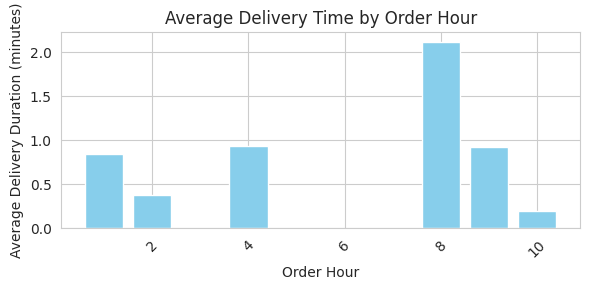

In [65]:
# Bar chart for Average Delivery Time by Order Hour
plt.figure(figsize=(6,3))
plt.bar(avg_by_hour.index,avg_by_hour.values,color='skyblue')
plt.title('Average Delivery Time by Order Hour')
plt.xlabel('Order Hour')
plt.ylabel('Average Delivery Duration (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

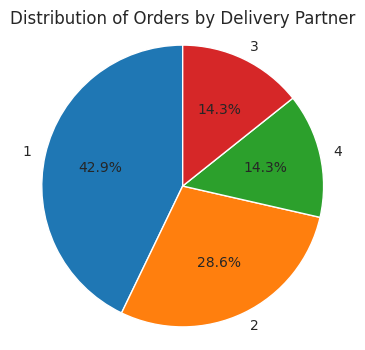

In [66]:
# Get the count of orders for each delivery partner
partner_counts=data['delivery partner'].value_counts()
plt.figure(figsize=(4,4))
plt.pie(partner_counts,labels=partner_counts.index,autopct='%1.1f%%',startangle=90)
plt.title('Distribution of Orders by Delivery Partner')
plt.axis('equal')
plt.show()

In [67]:
#performance Report
if avg_dvy_time>1.0:
  print("Need to improve  average delivery time.")
elif top_rated_partner<4.0:
  print("Need to improve customer ratings ")
else:
  print("Overall performance is good.")

Need to improve  average delivery time.
